Okay need to level up alittle yk, so we are going to begin to determine the breeds of theses Dogs and Cats. 

Structure: 
1. First Load the data 
2. Determine how to label the data 
3. How are we going to feed the model the data - what dataloader do we use 
4. Choose a Model 
5. Just run it 
6. Wrap it up about to be the meanest CS major this world has known 

In [4]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)

Step one done we got our data YAYYYYYYY!!!!!!!!!!!!!!!!

In [5]:
path.ls()

files = get_image_files(path/"images")

len(files)

7390

path.ls() - tells us where the files have been downloaded 

get_image_files(path/"images") - Indexes the whole file kinda like a list 

len(files) - we just checking if everything is working 

In [6]:
files[0]

Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg')

Path('/Users/shshankj/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_167.jpg')

So this really is outputing Egyptian_Mau_167.jpg

And so from the last try we know Capital letter for the first letter is a cat and Lower case is dog. Aside from this the whole string till the second _ is the breed. So we need to split the string. 

The ImageDataLoader needs to work on the basis of the filename. So theres are two options: 
1. ImageDataloader.from_name_re
2. ImageDataloader.from_name_func

re - just means regex https://www.w3schools.com/python/python_regex.asp

Link above is a good resource to learn about it 

func - just means we made a function prior and will use it in the dataloader function. 

We are going to be using the re one cause seems kinda cool (Claude may have helped with writing this :[)

In [9]:
import re 

name = files[0].name 

math = re.match(r"^(.+)_\d+.jpg$", name)

print(math.group(1))

Egyptian_Mau


In [10]:
pat = r'^(.+)_\d+\.jpg$'

dls = ImageDataLoaders.from_name_re(path, files, pat, valid_pct = 0.2 , item_tfms = Resize(460))

I didn't do it but there is a function called: 

batch_tfms=aug_transforms(size=224) - bassically crops the images randomly and forces the model to pick up on the patterns better. 

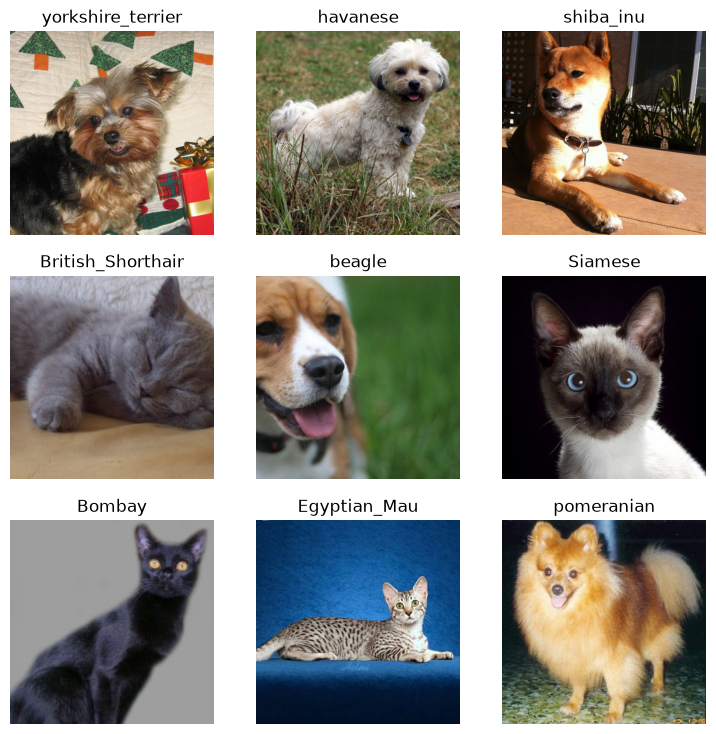

In [11]:
dls.show_batch()

<div></div>

SuggestedLRs(valley=0.0014454397605732083)

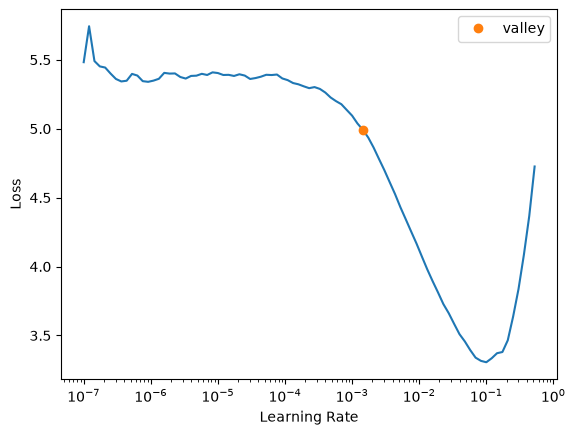

In [12]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

learn.lr_find()

So the plot helps us determine the max adjustments to make to the model each time we retrain/each epoch. So from the plot above the dot tells us to max make an adjustment of 1.4e-3. 

Reading your curve:
1. Flat and high on the left (10⁻⁷ to 10⁻⁴) → learning rate too tiny, no progress
2. Steep drop (10⁻³ to 10⁻¹) → the sweet spot, model learning fast
3. Sharp spike up past 10⁻¹ → too big, model going unstable



In [13]:
learn.fine_tune(3,1.4e-3)

epoch,train_loss,valid_loss,error_rate,time
0,2.035245,0.396078,0.125169,01:19


epoch,train_loss,valid_loss,error_rate,time
0,0.509111,0.237033,0.076455,01:49
1,0.289160,0.177239,0.055480,01:49
2,0.149605,0.144733,0.044655,01:49


We were guesing how many times to train the model, so a rule of thumb is: 

The real signal comes from the training table, not the lr_find graph. Once you start training, fastai shows you train_loss, valid_loss, and error_rate after every epoch. You watch those numbers to decide if you've run enough:

    Keep training if valid_loss and error_rate are still dropping each epoch — the model is still improving, so more epochs help.

    Stop when they flatten out (no more improvement) or — the key warning sign — when valid_loss starts rising while train_loss keeps falling. 

    That gap means overfitting: the model is memorizing training images instead of learning general patterns. That's your "too many epochs" signal.



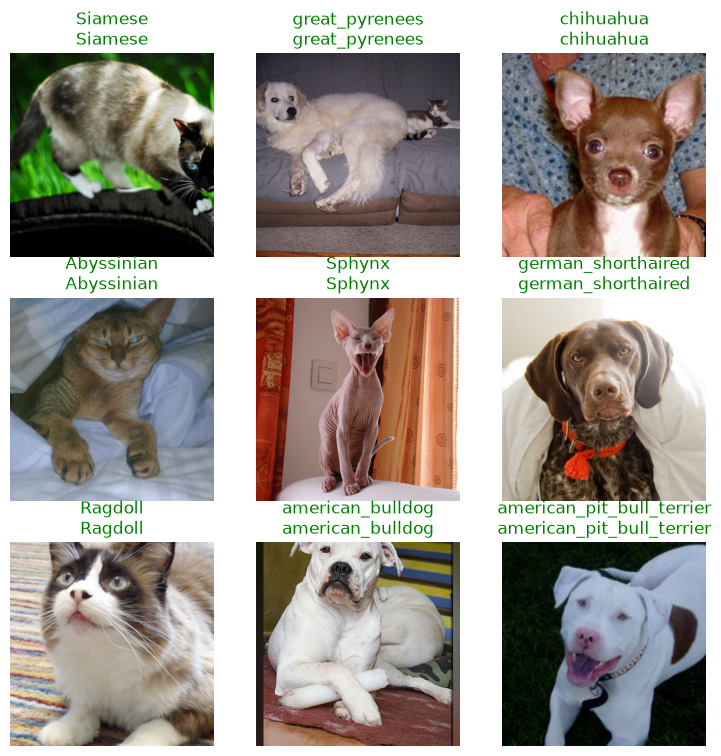

In [14]:
learn.show_results()